In [1]:
import pandas as pd
import numpy as np
import os
from sklearn import svm
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import scale
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import \
    train_test_split, StratifiedShuffleSplit, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score


from modules.matrix_processor import MatrixProcessor
import warnings
warnings.filterwarnings('ignore')

In [2]:
wps = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/cristiano_features/wps/EE87786_wps.csv')
wps_compute = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/cristiano_features/wps_compute/EE87786_wps_compute.csv')
fsr = pd.read_csv('/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/cristiano_features/fsr/EE87786_fsr.csv')

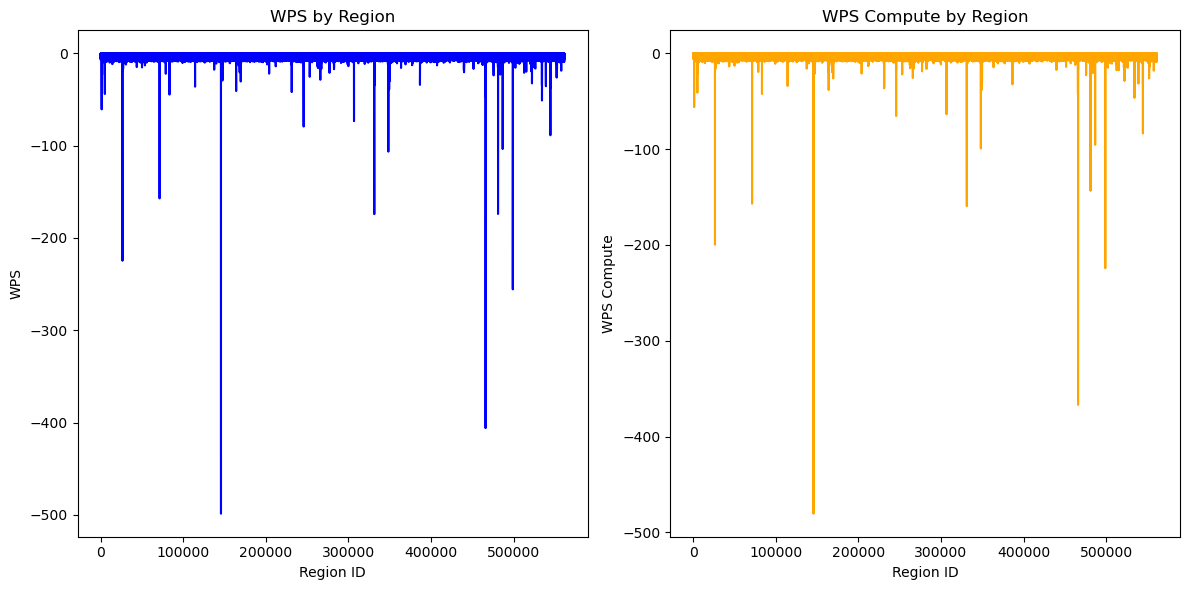

In [3]:
# plot side by side, region_id as x wps/wps_compute as y
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(wps['region_id'], wps['wps'], label='WPS', color='blue')
plt.xlabel('Region ID')
plt.ylabel('WPS')
plt.title('WPS by Region')
plt.subplot(1, 2, 2)
plt.plot(wps_compute['region_id'], wps_compute['wps_compute'], label='WPS Compute', color='orange')
plt.xlabel('Region ID')
plt.ylabel('WPS Compute')
plt.title('WPS Compute by Region')
plt.tight_layout()
plt.show()

In [17]:
df.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 'length'], dtype='object')

In [7]:
missing_samples = ["EE87920","EE87921","EE87977","EE87987","EE87999","EE88046","EE88056","EE88076","EE88087","EE88097","EE88108","EE88118","EE88130","EE88143","EE88155","EE88157","EE88158","EE88159","EE88160","EE88161","EE88165","EE88167"]
for sample in missing_samples:
    centroids_intersect = pd.read_csv(f'/data/projects/liquid_biopsy/Projects/cfDNA/cfDNA/data/sample_temp/{sample}_frag_centroids_openchrom_intersect.bed', sep='\t', header=None)
    cetroids_filtered = centroids_intersect[centroids_intersect[5] > 30]
    print(f'{sample:<20}: {"centroids_intersect":<20} {"centroids_filtered":<20}')
    print(f'{"" :<20} {len(centroids_intersect):<20} {len(cetroids_filtered):<20}')
    
    # print(centroids_intersect.describe())

EE87920             : centroids_intersect  centroids_filtered  
                     6690323              6593300             
EE87921             : centroids_intersect  centroids_filtered  
                     6522779              6429795             
EE87977             : centroids_intersect  centroids_filtered  
                     9756451              9598573             
EE87987             : centroids_intersect  centroids_filtered  
                     7393331              7272477             
EE87999             : centroids_intersect  centroids_filtered  
                     9094775              8945264             
EE88046             : centroids_intersect  centroids_filtered  
                     7479581              7359118             
EE88056             : centroids_intersect  centroids_filtered  
                     7181005              7059784             
EE88076             : centroids_intersect  centroids_filtered  
                     7714605              75821